<a href="https://colab.research.google.com/github/allybee271/BME450-Skin_Cancer_Identification/blob/main/BME450_Final_Proj_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kaggle Dataset: https://www.kaggle.com/datasets/nischaydnk/isic-2019-jpg-224x224-resized

Username: cailynbowerman

Token: KGAT_f7b309ac1ca7fbf6c747060a5b4288e9

In [ ]:
#Initialization
! pip install -q kaggle
! pip install opendatasets
!pip install -q scikit-learn
from sklearn.model_selection import train_test_split
import opendatasets as od
import pandas as pd
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
import os

od.download("https://www.kaggle.com/datasets/nischaydnk/isic-2019-jpg-224x224-resized")

df = pd.read_csv("/content/isic-2019-jpg-224x224-resized/train-metadata.csv")

df["image"] = df["isic_id"]
df["label"] = df["target"]

df = df[["image", "label"]]

In [ ]:
#Transforming Dataset to tensor

class ISICDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "image"] + ".jpg"
        label = self.df.loc[idx, "label"]

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

        from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)

test_df = test_df.sample(500)

#Dataset sampling (not used in this version)

#mel = train_df[train_df["label"] == 1].sample(500)
#nonmel = train_df[train_df["label"] == 0].sample(500)

#train_df = pd.concat([mel, nonmel]).sample(frac=1)


#Category Weighting
train_df = train_df.sample(2000)

num_nonmel = len(train_df[train_df["label"] == 0])
num_mel = len(train_df[train_df["label"] == 1])

pos_weight = torch.tensor([num_nonmel / num_mel])

pos_weight = torch.tensor([num_nonmel / num_mel])

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

IMG_DIR = "/content/isic-2019-jpg-224x224-resized/train-image/image"

training_data = ISICDataset(train_df, IMG_DIR, transform)
test_dataset = ISICDataset(test_df, IMG_DIR, transform)

#Batch size
train_dataloader = DataLoader(training_data, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16)

Inputs sample - image size: torch.Size([3, 128, 128])
Label: tensor(0.) 

Inputs sample - min,max,mean,std: 0.0 0.9607843160629272 0.23099006712436676 0.32641705870628357
Inputs sample normalized - min,max,mean,std: -0.7076531648635864 2.2357723712921143 1.7772739724364328e-08 1.0


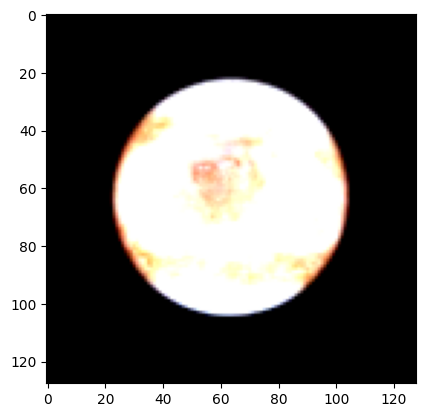

In [ ]:
categories = ['nonmelanoma','melanoma']#in datset melanoma is 1 and non is 0

#Cornfirming Tensor Formation

# select a random sample from the training set
sample_num = 1
print('Inputs sample - image size:', training_data[sample_num][0].shape)
print('Label:', training_data[sample_num][1], '\n')

import matplotlib.pyplot as plt

ima = training_data[sample_num][0]
print('Inputs sample - min,max,mean,std:', ima.min().item(), ima.max().item(), ima.mean().item(), ima.std().item())
ima = (ima - ima.mean())/ ima.std()
print('Inputs sample normalized - min,max,mean,std:', ima.min().item(), ima.max().item(), ima.mean().item(), ima.std().item())
iman = ima.permute(1, 2, 0) # needed to be able to plot
plt.imshow(iman)

In [ ]:
#Setting Probability Acceptance Threshold
threshold = 0.5

#CNN Model
class MobileCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Linear(16, 1)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

#Train Loop
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        y = y.float()
        pred = pred.squeeze()
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 20 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

#Test Loop
def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            y = y.float().unsqueeze(1)

            test_loss += loss_fn(pred, y).item()

            preds = (pred > threshold).float()
            probs = torch.sigmoid(pred)
            correct += (preds == y).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
from torchvision import models

model = MobileCNN()

#melanoma emphasize
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight) #Make empty parenthese if no weighting

learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 1.054249  [   16/ 2000]
loss: 1.055524  [  336/ 2000]
loss: 0.903489  [  656/ 2000]
loss: 1.053895  [  976/ 2000]
loss: 0.903410  [ 1296/ 2000]
loss: 1.054982  [ 1616/ 2000]
loss: 0.903486  [ 1936/ 2000]
Test Error: 
 Accuracy: 82.2%, Avg loss: 1.172393 

Epoch 2
-------------------------------
loss: 1.054540  [   16/ 2000]
loss: 1.205508  [  336/ 2000]
loss: 0.901977  [  656/ 2000]
loss: 1.201826  [  976/ 2000]
loss: 1.054366  [ 1296/ 2000]
loss: 1.358030  [ 1616/ 2000]
loss: 1.054233  [ 1936/ 2000]
Test Error: 
 Accuracy: 82.2%, Avg loss: 1.172393 

Epoch 3
-------------------------------
loss: 1.509309  [   16/ 2000]
loss: 1.207726  [  336/ 2000]
loss: 1.053140  [  656/ 2000]
loss: 1.052345  [  976/ 2000]
loss: 1.357973  [ 1296/ 2000]
loss: 0.751693  [ 1616/ 2000]
loss: 1.356289  [ 1936/ 2000]
Test Error: 
 Accuracy: 82.2%, Avg loss: 1.172393 

Epoch 4
-------------------------------
loss: 1.055018  [   16/ 2000]
loss: 0.900508  [  336/ 

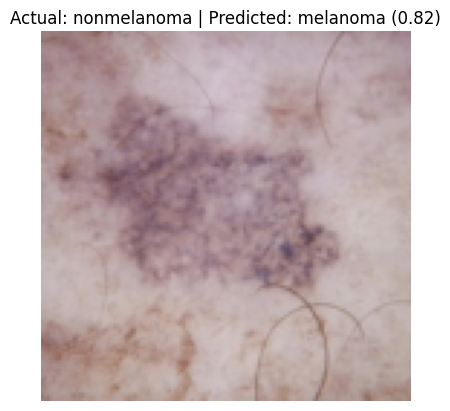

In [ ]:
sample, label = training_data[sample_num]
sample_input = sample.unsqueeze(0)

with torch.no_grad():
    output = model(sample_input)

prob = torch.sigmoid(output).item()
pred = 1 if prob > threshold else 0

plt.imshow(sample.permute(1,2,0))
plt.title(f"Actual: {categories[int(label)]} | Predicted: {categories[pred]} ({prob:.2f})")
plt.axis("off")
plt.show()

Number of melanoma images: 89


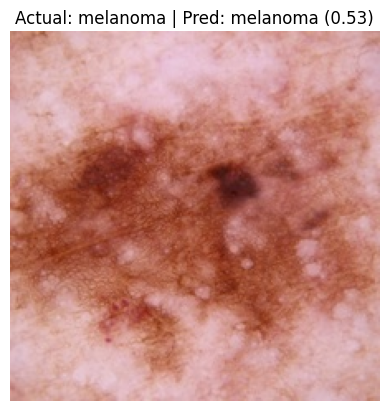

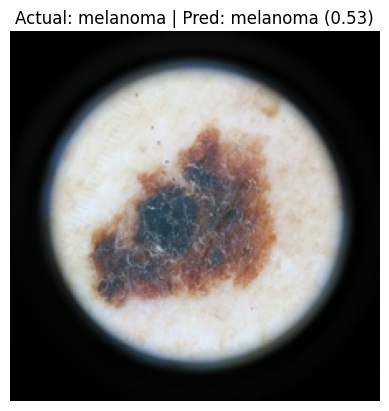

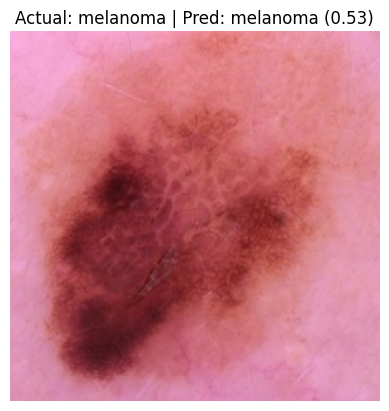

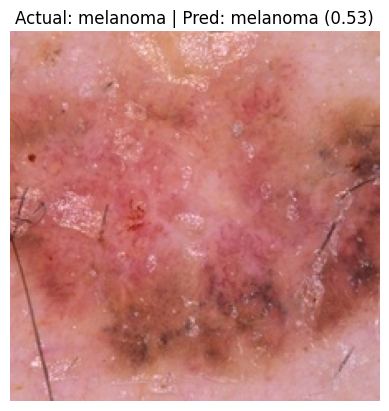

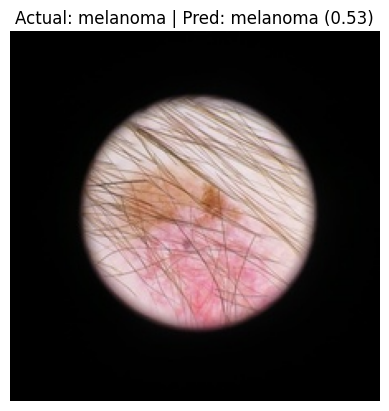

In [ ]:
#Printing Sample results
melanoma_df = test_df[test_df["label"] == 1]
print("Number of melanoma images:", len(melanoma_df))
samples = melanoma_df.sample(5, random_state=42)
import matplotlib.pyplot as plt
from PIL import Image
import os

categories = ["nonmelanoma", "melanoma"]

for i in range(len(samples)):
    row = samples.iloc[i]

    img_path = os.path.join(IMG_DIR, row["image"] + ".jpg")
    img = Image.open(img_path).convert("RGB")

    input_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)

    prob = torch.sigmoid(output).item()
    pred = 1 if prob > threshold else 0

    plt.figure()
    plt.imshow(img)
    plt.title(f"Actual: melanoma | Pred: {categories[pred]} ({prob:.2f})")
    plt.axis("off")
    plt.show()

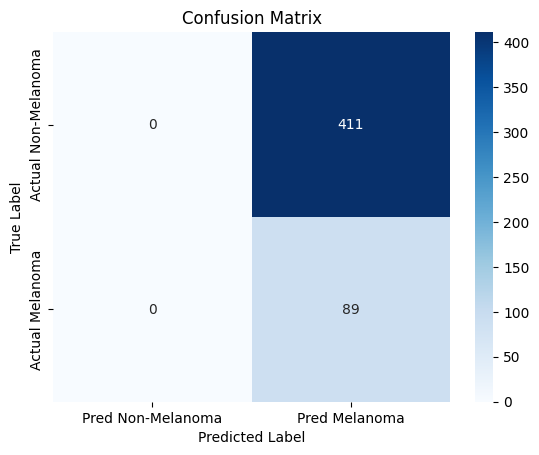

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X, y in test_dataloader:
        logits = model(X)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).int().squeeze()

        all_preds.extend(preds.tolist())
        all_labels.extend(y.int().tolist())



import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Non-Melanoma", "Pred Melanoma"],
            yticklabels=["Actual Non-Melanoma", "Actual Melanoma"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()